# Stress Level Prediction:
https://www.kaggle.com/datasets/shijo96john/stress-level-prediction/data


This dataset contains information related to individuals' lifestyle habits, health, and stress detection indicators. The dataset is structured with columns representing various factors that could influence or correlate with an individual's physical and mental well-being, particularly in relation to stress. Each row represents a unique individual with data points in several domains, such as sleep patterns, physical activity, diet, and health measurements.

Columns and their Description:

Age: The age of the individual.

Gender: Gender of the individual (Male/Female).

Occupation: The profession or job title of the individual.

Marital_Status: The marital status of the individual (e.g., Married, Single).

Sleep_Duration: The total amount of sleep an individual gets on average (in hours).

Sleep_Quality: Self-reported quality of sleep on a scale (e.g., 1-5).

Wake_Up_Time: The time the individual wakes up on average.

Bed_Time: The time the individual goes to bed on average.

Physical_Activity: Frequency of physical activity (e.g., number of days/week or a score).

Screen_Time: The average number of hours spent on electronic screens per day.

Caffeine_Intake: The average amount of caffeine consumed (e.g., cups of coffee).

Alcohol_Intake: The average amount of alcohol consumed (e.g., number of drinks per week).

Smoking_Habit: Whether the individual smokes (Yes/No).

Work_Hours: The number of hours worked per week.

Travel_Time: The time spent commuting (e.g., in hours per day).

Social_Interactions: The frequency of social interactions (e.g., number of social events attended).

Meditation_Practice: Whether the individual practices meditation (Yes/No).

Exercise_Type: The type of exercise the individual engages in (e.g., Yoga, Cardio, Strength Training).

Blood_Pressure: The individual's blood pressure level (e.g., 120/80).

Cholesterol_Level: The individual's cholesterol level (e.g., in mg/dL).

Blood_Sugar_Level: The individual's blood sugar level (e.g., in mg/dL).

Stress_Detection: A classification or indicator of the individual's stress level (e.g., High, Medium, Low).



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# ----------------------------
# 1. Load dataset
# ----------------------------

file_path = "/content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress level prediction/stress_detection_data.csv"
df = pd.read_csv(file_path)


# ----------------------------
# 2. Separate features and target
# ----------------------------
X = df.drop(columns=["Stress_Detection"])
y = df["Stress_Detection"]

# Identify categorical vs numeric columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

# ----------------------------
# 3. Preprocessing
# ----------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# ----------------------------
# 4. Build pipeline
# ----------------------------
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
])

# ----------------------------
# 5. Train-test split (80/20)
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ----------------------------
# 6. Train model
# ----------------------------
model.fit(X_train, y_train)

# ----------------------------
# 7. Evaluate
# ----------------------------
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Accuracy: 0.7419354838709677

Classification Report:
              precision    recall  f1-score   support

        High       0.82      0.78      0.80        60
         Low       0.82      0.42      0.56        33
      Medium       0.67      0.87      0.76        62

    accuracy                           0.74       155
   macro avg       0.77      0.69      0.71       155
weighted avg       0.76      0.74      0.73       155



In [ ]:
# =============================================================
# 0) Mount Google Drive
# =============================================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# =============================================================
# 1) Load dataset from Google Drive
# =============================================================
file_path = "/content/drive/My Drive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress level prediction/stress_detection_data.csv"

df = pd.read_csv(file_path)
print("Loaded dataset shape:", df.shape)

# =============================================================
# 2) Split features and labels
# =============================================================
X = df.drop(columns=["Stress_Detection"])
y = df["Stress_Detection"]

# ---- Encode labels to integers for XGBoost (and others) ----
le = LabelEncoder()
y_encoded = le.fit_transform(y)    # 'High','Low','Medium' -> 0,1,2 (order is le.classes_)
print("Label classes:", le.classes_)

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", numeric_cols)
])

# =============================================================
# 3) Train-test split (using encoded labels)
# =============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

# =============================================================
# 4) Define Models + Hyperparameter Grids
# =============================================================
models = {
    "Logistic Regression": (
        Pipeline([
            ("preprocess", preprocess),
            ("clf", LogisticRegression(max_iter=2000, multi_class="multinomial"))
        ]),
        {"clf__C": [0.1, 1, 5]}
    ),

    "Linear SVM": (
        Pipeline([
            ("preprocess", preprocess),
            ("clf", LinearSVC())
        ]),
        {"clf__C": [0.1, 1, 5]}
    ),

    "Random Forest": (
        Pipeline([
            ("preprocess", preprocess),
            ("clf", RandomForestClassifier(random_state=42))
        ]),
        {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [None, 10, 20]
        }
    ),

    "XGBoost": (
        Pipeline([
            ("preprocess", preprocess),
            ("clf", XGBClassifier(
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=42
            ))
        ]),
        {
            "clf__n_estimators": [100, 200],
            "clf__learning_rate": [0.05, 0.1],
            "clf__max_depth": [3, 5]
        }
    )
}

# =============================================================
# 5) Run grid search + evaluate each model
# =============================================================
best_results = {}

for name, (pipeline, params) in models.items():
    print(f"\n==============================")
    print(f"Training: {name}")
    print("==============================")

    grid = GridSearchCV(
        pipeline,
        params,
        scoring="f1_macro",
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)

    # Macro F1 on encoded labels
    f1 = f1_score(y_test, y_pred, average="macro")
    best_results[name] = f1

    # Decode back to original string labels for reporting
    y_test_labels = le.inverse_transform(y_test)
    y_pred_labels = le.inverse_transform(y_pred)

    print(f"\nBest F1 (macro): {f1:.4f}")
    print("Best Params:", grid.best_params_)
    print("\nClassification Report:\n",
          classification_report(y_test_labels, y_pred_labels, labels=le.classes_))

# =============================================================
# 6) Final comparison
# =============================================================
print("\n\n====== Final Model Comparison (Macro F1) ======")
for model, score in best_results.items():
    print(f"{model}: {score:.4f}")

best_model = max(best_results, key=best_results.get)
print("\n⭐⭐ Best model overall:", best_model, "⭐⭐")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded dataset shape: (773, 22)
Label classes: ['High' 'Low' 'Medium']

Training: Logistic Regression
Fitting 5 folds for each of 3 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Best F1 (macro): 0.6478
Best Params: {'clf__C': 0.1}

Classification Report:
               precision    recall  f1-score   support

        High       0.71      0.68      0.69        60
         Low       0.71      0.52      0.60        33
      Medium       0.60      0.71      0.65        62

    accuracy                           0.66       155
   macro avg       0.67      0.64      0.65       155
weighted avg       0.67      0.66      0.66       155


Training: Linear SVM
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best F1 (macro): 0.6013
Best Params: {'clf__C': 1}

Classification Report:
               precision    recall  f1-score   support

        High       0.68      0.73      0.70        60
         Low       0.60      0.45      0.52        33
      Medium       0.57      0.60      0.58        62

    accuracy                           0.62       155
   macro avg       0.62      0.59      0.60       155
weighted avg       0.62      0.62      0.62       155



Number of encoded features: 216


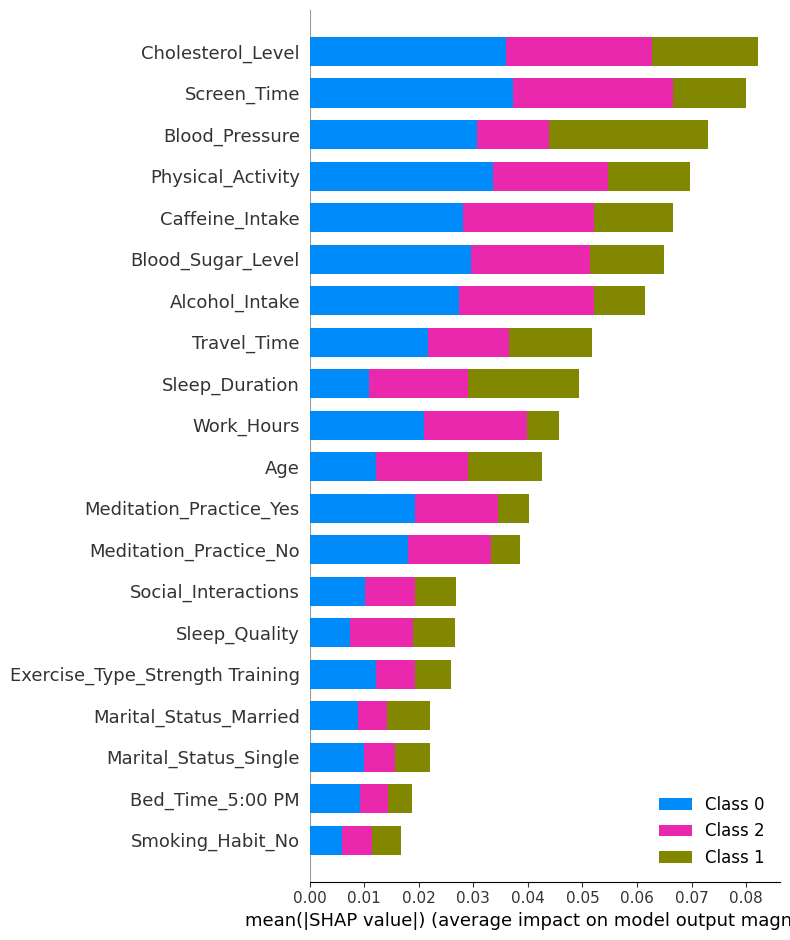

In [ ]:
# =============================================================
# SHAP Analysis for Best Model: Random Forest
# =============================================================
import shap
import numpy as np
from scipy import sparse

shap.initjs()

# 1. Refit Best Random Forest (if not already done)
best_rf = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42
    ))
])
best_rf.fit(X_train, y_train)

# 2. Extract preprocessor and RF model
preprocessor = best_rf.named_steps["preprocess"]
rf_model = best_rf.named_steps["clf"]

# 3. Transform X into encoded space
X_train_enc = preprocessor.transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

# 3a. Convert to dense float arrays (SHAP needs numeric array, not object/sparse)
if sparse.issparse(X_train_enc):
    X_train_enc = X_train_enc.toarray()
if sparse.issparse(X_test_enc):
    X_test_enc = X_test_enc.toarray()

X_train_enc = X_train_enc.astype("float32")
X_test_enc  = X_test_enc.astype("float32")

# 4. Get feature names after OneHotEncoder
ohe = preprocessor.named_transformers_["cat"]
encoded_cat_cols = ohe.get_feature_names_out(categorical_cols)
feature_names = np.concatenate([encoded_cat_cols, numeric_cols])
print("Number of encoded features:", len(feature_names))

# 5. Create SHAP TreeExplainer
explainer = shap.TreeExplainer(rf_model)

# 6. Compute SHAP values for the test set (multi-class list: [class0, class1, class2])
shap_values = explainer.shap_values(X_test_enc)

# 7. Global feature importance (bar plot on mean |SHAP|)
class_labels = ["High", "Medium", "Low"]
shap.summary_plot(shap_values, X_test_enc, feature_names=feature_names, plot_type="bar")


In [ ]:
import numpy as np
import pandas as pd

class_labels = ["High", "Medium", "Low"]

print("shap_values.shape:", shap_values.shape)
print("X_test_enc.shape:", X_test_enc.shape)
print("len(feature_names):", len(feature_names))

n_samples, n_features, n_classes = shap_values.shape

top_features_per_class = {}

for class_idx, class_name in enumerate(class_labels):
    # shap_values: [samples, features, classes]
    # Take SHAP for this class: shape (n_samples, n_features)
    sv_class = shap_values[:, :, class_idx]

    # Mean |SHAP| over samples → importance per feature
    mean_abs = np.mean(np.abs(sv_class), axis=0)  # length = n_features

    df_importance = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs
    }).sort_values("mean_abs_shap", ascending=False)

    top_features_per_class[class_name] = df_importance.head(10)

    print(f"\n==============================")
    print(f"Top 10 Features for Class: {class_name}")
    print("==============================")
    print(df_importance.head(10))


shap_values.shape: (155, 216, 3)
X_test_enc.shape: (155, 216)
len(feature_names): 216

Top 10 Features for Class: High
                     feature  mean_abs_shap
207              Screen_Time       0.037185
214        Cholesterol_Level       0.035957
206        Physical_Activity       0.033546
213           Blood_Pressure       0.030638
215        Blood_Sugar_Level       0.029603
208          Caffeine_Intake       0.028097
209           Alcohol_Intake       0.027428
211              Travel_Time       0.021760
210               Work_Hours       0.021012
195  Meditation_Practice_Yes       0.019353

Top 10 Features for Class: Medium
               feature  mean_abs_shap
213     Blood_Pressure       0.029166
204     Sleep_Duration       0.020297
214  Cholesterol_Level       0.019417
211        Travel_Time       0.015210
206  Physical_Activity       0.015077
208    Caffeine_Intake       0.014360
215  Blood_Sugar_Level       0.013663
203                Age       0.013503
207        Screen_Ti

# Stress detection
https://www.kaggle.com/datasets/swadeshi/stress-detection-dataset

This dataset consists of 3000 rows, representing daily data for 100 participants over a period of 30 days. The data captures various psychological, behavioral, and physiological attributes for each participant. Below is a breakdown of the columns:

participant_id:

Unique identifier for each participant.
Data type: Integer
Range: 1 to 100 (as there are 100 participants)
day:

The day of observation for each participant.
Data type: Integer
Range: 1 to 30 (each participant is observed over 30 days)
PSS_score:

Perceived Stress Scale score, measuring stress levels.
Data type: Integer
Range: 10 to 40
Openness:

Measure of openness to experience, a personality trait.
Data type: Float
Range: 1.0 to 5.0
Conscientiousness:

Measure of conscientiousness, a personality trait.
Data type: Float
Range: 1.0 to 5.0
Extraversion:

Measure of extraversion, a personality trait.
Data type: Float
Range: 1.0 to 5.0
Agreeableness:

Measure of agreeableness, a personality trait.
Data type: Float
Range: 1.0 to 5.0

Neuroticism:

Measure of neuroticism, a personality trait.
Data type: Float
Range: 1.0 to 5.0

sleep_time:

The time (in hours) the participant went to sleep.
Data type: Float
Range: 5.0 to 9.0 hours

wake_time:

The time (in hours) the participant woke up.
Data type: Float
Range: 5.0 to 9.0 hours

sleep_duration:

The duration (in hours) the participant slept.
Data type: Float
Range: 6.0 to 9.0 hours

PSQI_score:

Pittsburgh Sleep Quality Index (PSQI) score, measuring sleep quality.
Data type: Integer
Range: 1 to 5

call_duration:

Total duration of phone calls for the day (in minutes).
Data type: Float
Range: 0 to 60 minutes

num_calls:

Number of phone calls made during the day.
Data type: Integer
Range: 0 to 20 calls

num_sms:

Number of SMS messages sent during the day.
Data type: Integer
Range: 0 to 50 messages

screen_on_time:

Total screen-on time for the day (in hours).
Data type: Float
Range: 1.0 to 12.0 hours

skin_conductance:

Measure of skin conductance, indicating arousal or stress response.
Data type: Float
Range: 0.5 to 5.0 µS (microsiemens)

accelerometer:

Accelerometer data representing physical movement.
Data type: Float
Range: 0.1 to 2.5 g (g-force)

mobility_radius:

The radius of mobility for the participant (in kilometers).
Data type: Float
Range: 0.1 to 1.5 km

mobility_distance:

Total distance moved during the day (in kilometers).
Data type: Float
Range: 0.5 to 5.0 km

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data shape: (3000, 20)


,participant_id,day,PSS_score,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism,sleep_time,wake_time,sleep_duration,PSQI_score,call_duration,num_calls,num_sms,screen_on_time,skin_conductance,accelerometer,mobility_radius,mobility_distance
0,1,1,34,2.322732,4.332193,1.185878,1.570213,3.782094,7.726792,5.190660,6.572069,1,3.924527,12,32,10.703714,3.115730,0.161717,1.145179,2.196851
1,1,2,37,1.761436,3.254120,3.907281,4.072512,1.997145,7.312674,6.170717,8.030168,4,58.318004,3,41,11.012939,0.959144,0.985587,1.021133,0.737825
2,1,3,30,3.025887,1.855002,2.045900,2.317493,3.619225,6.992060,5.318825,7.102420,1,4.941043,4,48,4.877372,3.311629,1.877445,0.478179,0.911673
3,1,4,16,1.948370,4.966676,3.345225,1.607756,3.583524,8.886914,8.061075,8.123294,3,0.295373,11,38,3.462956,0.625721,0.494921,0.630549,3.911418
4,1,5,32,3.343484,2.065936,3.137843,2.118061,2.567347,7.811705,7.312145,7.785143,3,22.300571,17,17,4.861046,0.622609,1.342600,0.254090,1.605132



Label distribution:
stress_level
high      1342
medium    1280
low        378
Name: count, dtype: int64

Features: ['participant_id', 'day', 'Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism', 'sleep_time', 'wake_time', 'sleep_duration', 'PSQI_score', 'call_duration', 'num_calls', 'num_sms', 'screen_on_time', 'skin_conductance', 'accelerometer', 'mobility_radius', 'mobility_distance']

Encoded classes (index -> label):
0 -> high
1 -> low
2 -> medium

Train size: (2400, 19) Test size: (600, 19)

Training model: logistic_regression
Best params: {'clf__C': 1}
Test F1 (weighted): 0.40719194191635133
Classification report:
              precision    recall  f1-score   support

        high       0.45      0.59      0.51       268
         low       0.00      0.00      0.00        76
      medium       0.42      0.41      0.42       256

    accuracy                           0.44       600
   macro avg       0.29      0.33      0.31       600
weighted avg      

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: 

Best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Test F1 (weighted): 0.38262035904334396
Classification report:
              precision    recall  f1-score   support

        high       0.42      0.46      0.44       268
         low       0.05      0.03      0.03        76
      medium       0.42      0.43      0.42       256

    accuracy                           0.40       600
   macro avg       0.30      0.31      0.30       600
weighted avg       0.37      0.40      0.38       600


Training model: random_forest
Best params: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Test F1 (weighted): 0.4066654812707444
Classification report:
              precision    recall  f1-score   support

        high       0.44      0.53      0.48       268
         low       0.00      0.00      0.00        76
      medium       0.43      0.46      0.45       256

    accuracy                           0.44       600
   macro avg       0.29  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
Test F1 (weighted): 0.37976375610792434
Classification report:
              precision    recall  f1-score   support

        high       0.42      0.52      0.47       268
         low       0.00      0.00      0.00        76
      medium       0.39      0.41      0.40       256

    accuracy                           0.41       600
   macro avg       0.27      0.31      0.29       600
weighted avg       0.36      0.41      0.38       600


Best overall model: logistic_regression
Best F1 (weighted): 0.40719194191635133
Best model pipeline:
Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(C=1, max_iter=2000,
                                    multi_class='multinomial',
                                    random_state=42))])



------------------------------------------------------------
SHAP analysis for model: logistic_regression
------------------------------------------------------------


  0%|          | 0/600 [00:00<?, ?it/s]

Plotting SHAP summary for model: logistic_regression


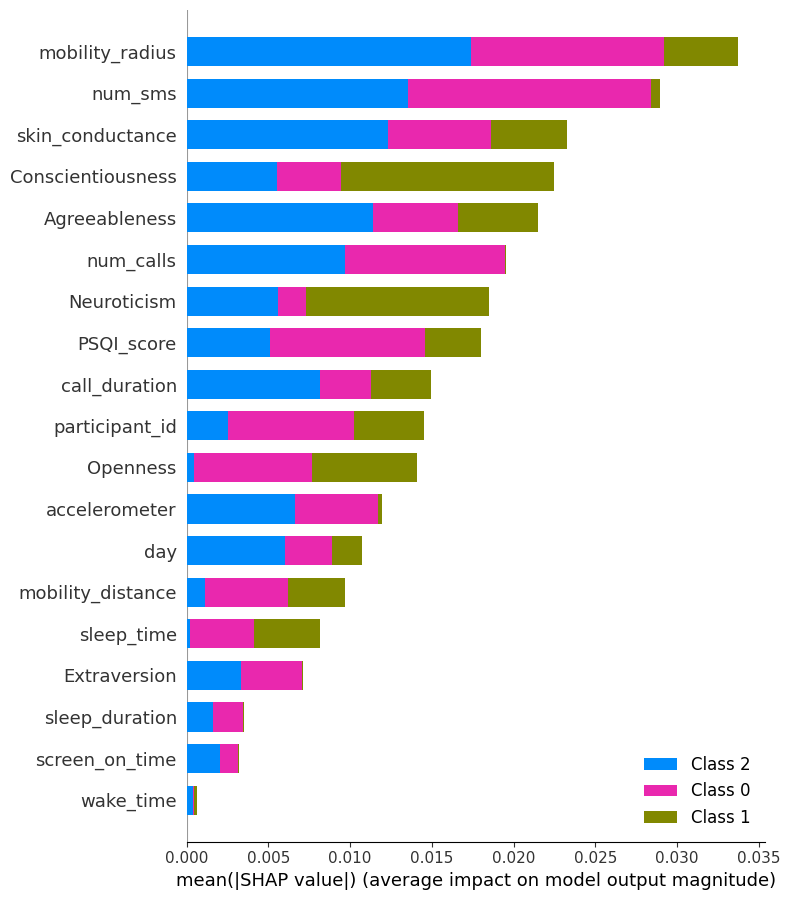


------------------------------------------------------------
SHAP analysis for model: svm
------------------------------------------------------------


  0%|          | 0/600 [00:00<?, ?it/s]

Plotting SHAP summary for model: svm


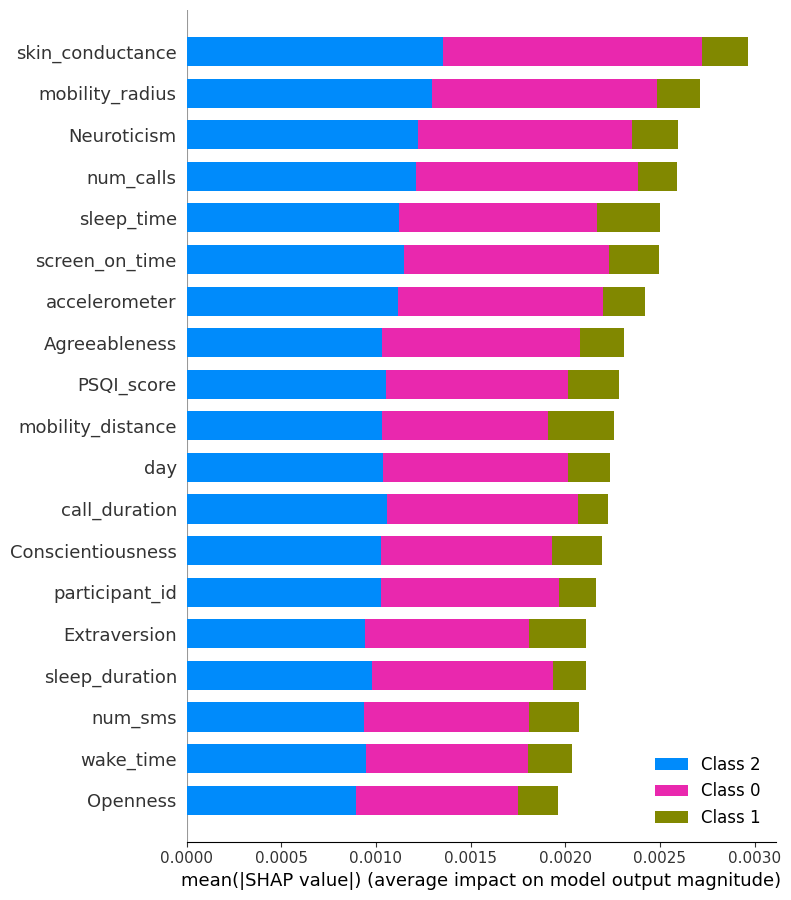


------------------------------------------------------------
SHAP analysis for model: random_forest
------------------------------------------------------------
Plotting SHAP summary for model: random_forest


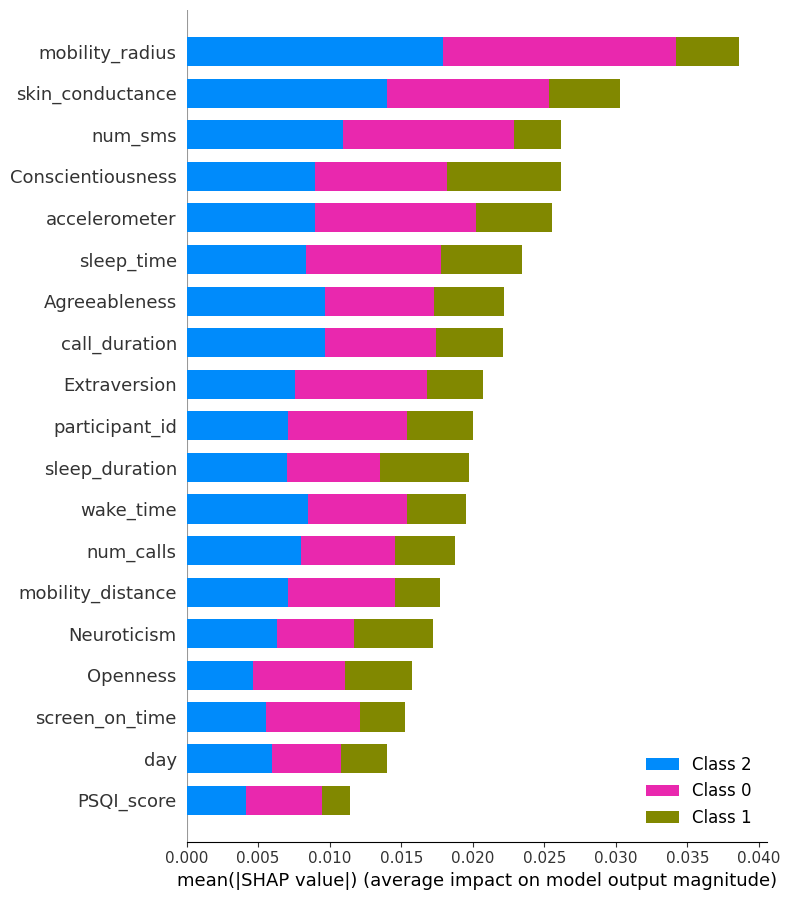


------------------------------------------------------------
SHAP analysis for model: xgboost
------------------------------------------------------------
Plotting SHAP summary for model: xgboost


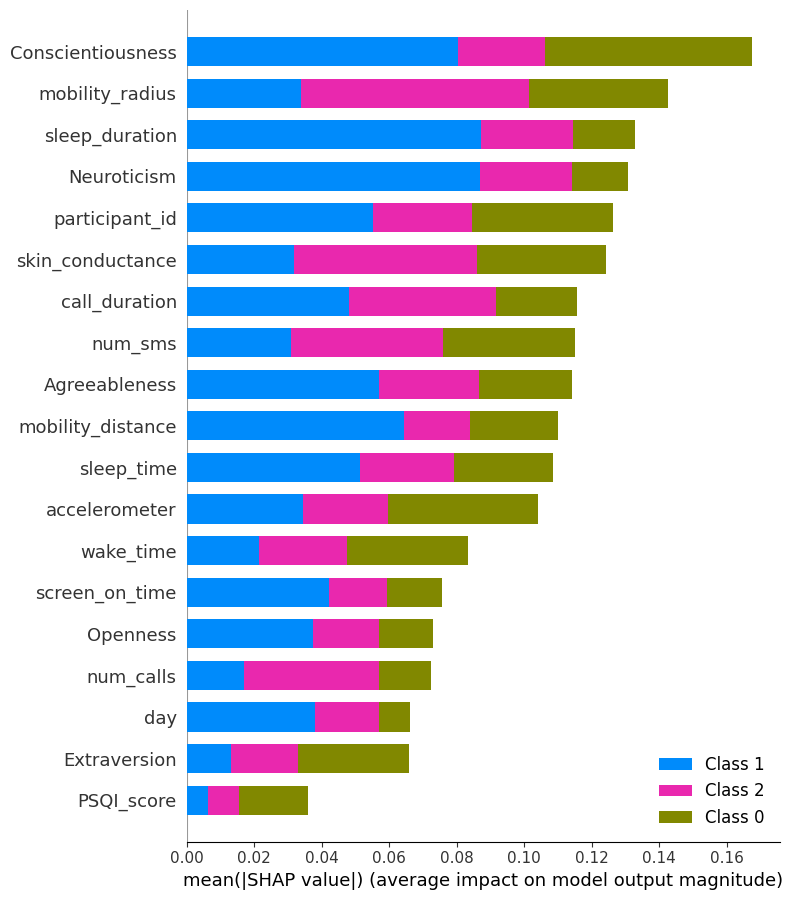


Per class SHAP plots for best model: logistic_regression
Class order in model (integer labels): [0 1 2]
Class names from LabelEncoder: ['high' 'low' 'medium']
Best model SHAP is not multi class list, cannot split per class cleanly.


In [5]:
# =============================================================
# 0) Imports
# =============================================================
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# You need: pip install xgboost shap (run in a separate cell if not installed)
from xgboost import XGBClassifier
import shap

# For plotting
import matplotlib.pyplot as plt

# Make plots a bit larger
plt.rcParams["figure.figsize"] = (8, 6)

# =============================================================
# 1) Load dataset from Google Drive
# =============================================================
from google.colab import drive
drive.mount('/content/drive')

csv_path = "/content/drive/MyDrive/Rice University/25fall/ELEC509/Final Project/Dataset/Stress detection/stress_detection.csv"

df = pd.read_csv(csv_path)

print("Data shape:", df.shape)
display(df.head())

# =============================================================
# 2) Create target labels: low, medium, high
#    PSS_score: 0-13 low, 14-26 medium, 27-40 high
# =============================================================
def pss_to_label(pss):
    if pss <= 13:
        return "low"
    elif pss <= 26:
        return "medium"
    else:
        return "high"

df["stress_level"] = df["PSS_score"].apply(pss_to_label)
print("\nLabel distribution:")
print(df["stress_level"].value_counts())

# =============================================================
# 3) Feature matrix X and encoded label y
# =============================================================
drop_cols = ["PSS_score", "stress_level"]
X = df.drop(columns=drop_cols)

# Encode labels as integers for all models (needed for XGBoost)
le = LabelEncoder()
y_encoded = le.fit_transform(df["stress_level"])  # 0,1,2

feature_names = X.columns.tolist()
print("\nFeatures:", feature_names)
print("\nEncoded classes (index -> label):")
for idx, label in enumerate(le.classes_):
    print(idx, "->", label)

# Train test split
X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("\nTrain size:", X_train.shape, "Test size:", X_test.shape)

# =============================================================
# 4) Define models and hyperparameter grids
# =============================================================
models = {}

# 4.1 Logistic Regression
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        max_iter=2000,
        random_state=42
    ))
])
param_grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10]
}
models["logistic_regression"] = (pipe_lr, param_grid_lr)

# 4.2 SVM
pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(probability=True, random_state=42))
])
param_grid_svm = {
    "clf__C": [0.1, 1, 10],
    "clf__gamma": ["scale", "auto"],
    "clf__kernel": ["rbf"]
}
models["svm"] = (pipe_svm, param_grid_svm)

# 4.3 Random Forest
pipe_rf = Pipeline([
    ("clf", RandomForestClassifier(random_state=42))
])
param_grid_rf = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [None, 5, 10, 20],
    "clf__min_samples_split": [2, 5]
}
models["random_forest"] = (pipe_rf, param_grid_rf)

# 4.4 XGBoost
pipe_xgb = Pipeline([
    ("clf", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        tree_method="hist"  # faster
    ))
])
param_grid_xgb = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.05, 0.1],
    "clf__subsample": [0.8, 1.0]
}
models["xgboost"] = (pipe_xgb, param_grid_xgb)

# =============================================================
# 5) Train and evaluate all models
# =============================================================
best_models = {}
scores = {}

for name, (pipe, param_grid) in models.items():
    print("\n============================================================")
    print(f"Training model: {name}")
    print("============================================================")

    grid = GridSearchCV(
        pipe,
        param_grid,
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1
    )
    grid.fit(X_train, y_train_enc)

    print("Best params:", grid.best_params_)

    # Evaluate on test (predictions as integers)
    y_pred_enc = grid.predict(X_test)

    # Convert back to labels for readable report
    y_pred = le.inverse_transform(y_pred_enc)
    y_test = le.inverse_transform(y_test_enc)

    f1 = f1_score(y_test, y_pred, average="weighted")
    print("Test F1 (weighted):", f1)
    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    best_models[name] = grid.best_estimator_
    scores[name] = f1

# =============================================================
# 6) Pick overall best model
# =============================================================
best_model_name = max(scores, key=scores.get)
best_model = best_models[best_model_name]

print("\n============================================================")
print("Best overall model:", best_model_name)
print("Best F1 (weighted):", scores[best_model_name])
print("Best model pipeline:")
print(best_model)

# =============================================================
# 7) SHAP analysis helper functions
# =============================================================
def compute_shap_for_model(name, model, X_train, X_test, feature_names):
    """
    Returns explainer, shap_values, X_test_enc
    shap_values for:
    - list of arrays, one per class, for tree based models
    - list of arrays (one per class) for KernelExplainer with predict_proba
    """
    print(f"\n------------------------------------------------------------")
    print(f"SHAP analysis for model: {name}")
    print("------------------------------------------------------------")

    # Separate preprocessing and classifier
    if isinstance(model, Pipeline):
        clf = model.named_steps["clf"]
        step_names = list(model.named_steps.keys())
        if len(step_names) > 1:
            # all steps except last are preprocessing
            preproc = model[:-1]
        else:
            preproc = None
    else:
        preproc = None
        clf = model

    if preproc is not None:
        X_train_enc = preproc.transform(X_train)
        X_test_enc = preproc.transform(X_test)
    else:
        X_train_enc = X_train.values
        X_test_enc = X_test.values

    # Convert to numpy float
    X_train_enc = np.array(X_train_enc, dtype=float)
    X_test_enc = np.array(X_test_enc, dtype=float)

    # Choose SHAP explainer type
    if isinstance(clf, (RandomForestClassifier, XGBClassifier)):
        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_test_enc)
    elif isinstance(clf, (LogisticRegression, SVC)):
        # Use KernelExplainer for generic models
        # For speed, sample background
        n_bg = min(200, X_train_enc.shape[0])
        background = X_train_enc[np.random.choice(X_train_enc.shape[0], n_bg, replace=False)]
        explainer = shap.KernelExplainer(clf.predict_proba, background)
        shap_values = explainer.shap_values(X_test_enc, nsamples=200)
    else:
        raise ValueError("Unknown classifier type for SHAP")

    return explainer, shap_values, X_test_enc

def plot_shap_summary_for_model(name, shap_values, X_test_enc, feature_names, class_names):
    """
    Plot global SHAP importance for each model
    If multi class, shap_values is list of arrays for each class
    """
    print(f"Plotting SHAP summary for model: {name}")

    # Multi class case
    if isinstance(shap_values, list):
        shap.summary_plot(
            shap_values,
            X_test_enc,
            feature_names=feature_names,
            class_names=class_names,
            plot_type="bar",
            show=True
        )
    else:
        shap.summary_plot(
            shap_values,
            X_test_enc,
            feature_names=feature_names,
            plot_type="bar",
            show=True
        )

# Initialize JS for notebook
shap.initjs()

# Class names from label encoder
class_names = list(le.classes_)

# =============================================================
# 8) SHAP plots for each model
# =============================================================
shap_results = {}

for name, model in best_models.items():
    explainer, shap_values, X_test_enc = compute_shap_for_model(
        name, model, X_train, X_test, feature_names
    )
    shap_results[name] = (explainer, shap_values, X_test_enc)

    # Global summary per model (bar plot)
    plot_shap_summary_for_model(
        name,
        shap_values,
        X_test_enc,
        feature_names,
        class_names
    )

# =============================================================
# 9) For the best model: separate SHAP summary for low, medium, high
# =============================================================
print("\n============================================================")
print("Per class SHAP plots for best model:", best_model_name)
print("============================================================")

explainer_best, shap_values_best, X_test_enc_best = shap_results[best_model_name]

# Extract classifier
if isinstance(best_model, Pipeline):
    clf_best = best_model.named_steps["clf"]
else:
    clf_best = best_model

classes_order = clf_best.classes_  # integer labels
print("Class order in model (integer labels):", classes_order)
print("Class names from LabelEncoder:", le.classes_)

# For multi class models, shap_values_best is a list: [class0, class1, class2]
if isinstance(shap_values_best, list):
    # Loop over encoder classes; index corresponds to integer label
    for idx, label in enumerate(le.classes_):
        print(f"\nSHAP summary for class: {label} (index {idx})")
        shap.summary_plot(
            shap_values_best[idx],
            X_test_enc_best,
            feature_names=feature_names,
            show=True
        )
else:
    print("Best model SHAP is not multi class list, cannot split per class cleanly.")
